## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory data Analysis (EDA)

##### . Here we simply look at the data before touching it.
##### . We want to understand it first, then work on it.


### Basic info about the data 


In [3]:
df.shape

(32581, 12)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


### Missing values

In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Target balance

In [6]:
df.head()
df['loan_status'].unique()
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

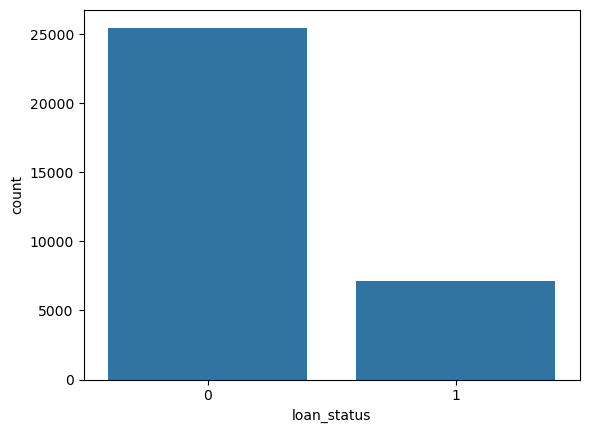

In [7]:
sns.countplot(x = df['loan_status'])

### Oultlier Check

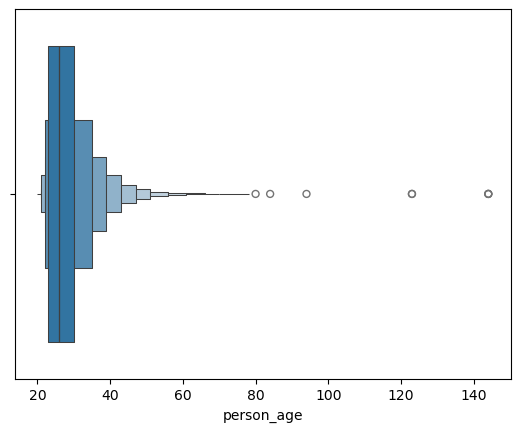

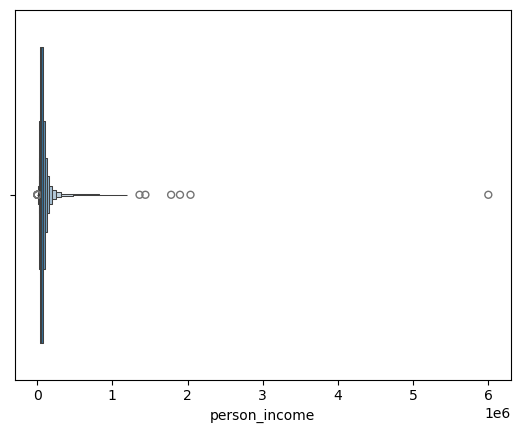

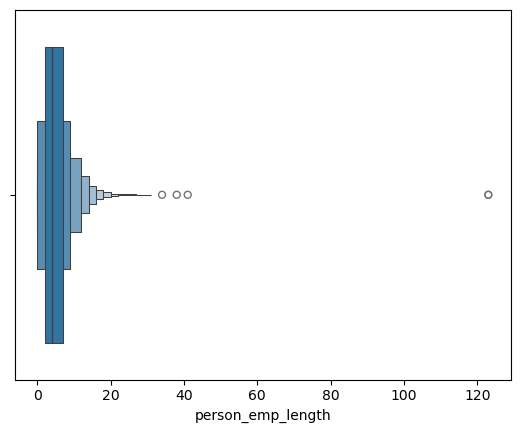

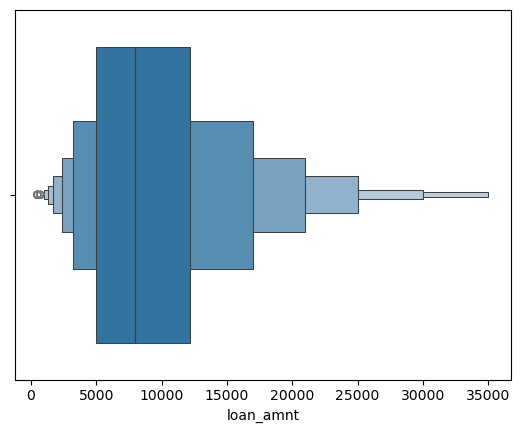

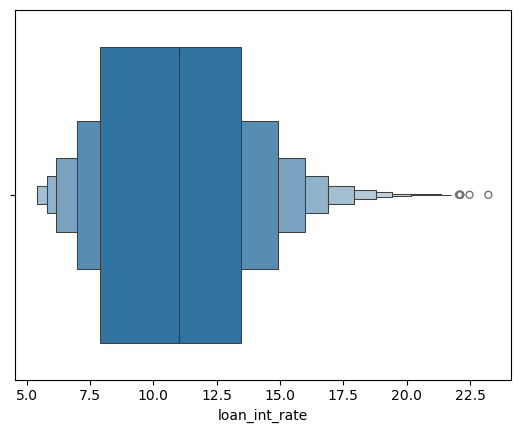

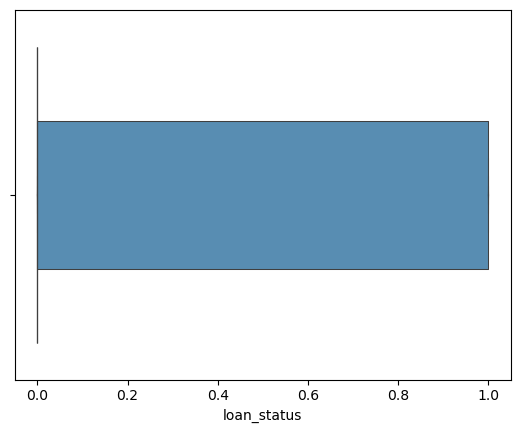

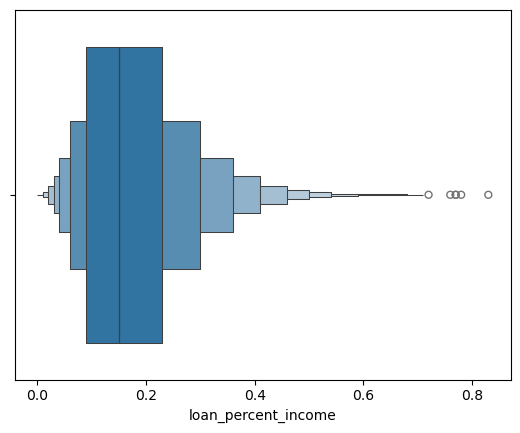

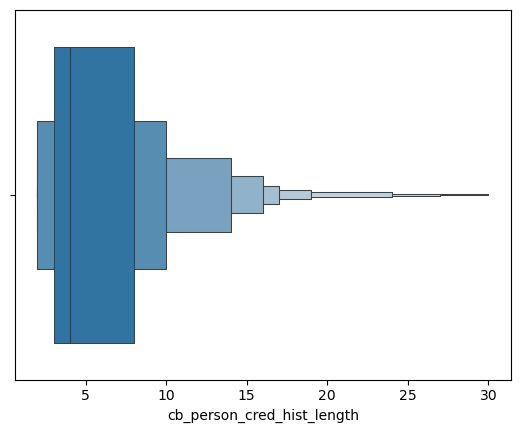

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
    sns.boxenplot(x = df[i])
    plt.show()

    

In [9]:
(df['person_age'] > 100).sum()

5

In [10]:
(df['person_emp_length'] > 60).sum()

2

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### correlation check

<Axes: >

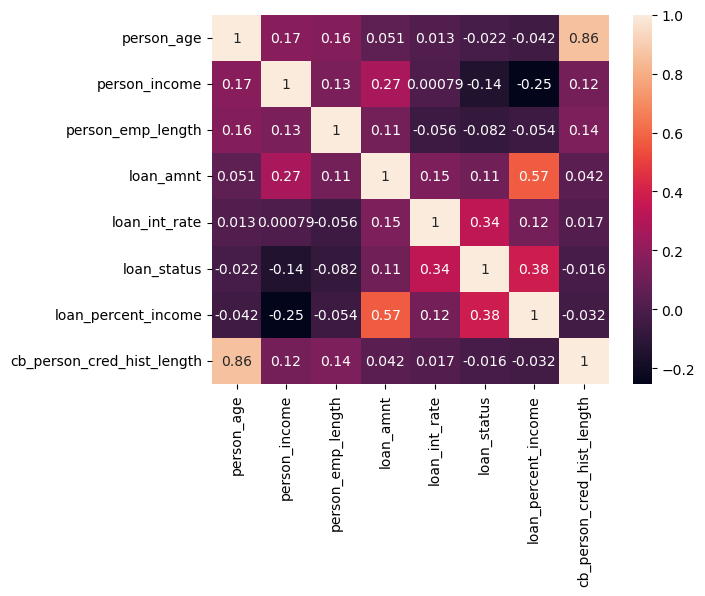

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

## 3. Data Validation & Outlier Handling 

In [13]:
df_copy = df.copy()

In [14]:
print(f'original Rows : {df_copy.shape[0]}')
# remove duplicate rows

df_copy.drop_duplicates(inplace=True)
print(f'Rows after removing duplicates : {df_copy.shape[0]}')

# remove ages below 18 and above 100
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# remove employment length greater than age or extreme utliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60 ]

#remove the rows of the zeros income or negevative income and loan amount
df_copy = df_copy[df_copy['loan_amnt']>0]

# check if the intrest rate looks realistics
print('loan intrest rate range  from (min: 5.42 and max: 23.22')

original Rows : 32581
Rows after removing duplicates : 32416
loan intrest rate range  from (min: 5.42 and max: 23.22


## 4. Features, Target & train-test split

In [15]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [17]:

numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle class imbalance

In [18]:
# 0 --> no loan (most)
# 1 ---> yes loan 

neg ,pos = np.bincount(y_train)
scale_weights = neg/pos

In [19]:
scale_weights

3.6312213039485766

## 6. Data Preprocessing -- Piplines & Column Transformers

### preprocessing for Logistic Regression

In [20]:
# Logistic Regression : impute + scale numeric, impute + one Hot enconding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers = [
        # Pipline - for numerical cols
        ('num', Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        # pipline - for categorical cols
        ('cat',Pipeline([
            ('imputer', SimpleImputer(strategy = 'constant',fill_value = 'Missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])



### Preprocessing for XGBoost

In [21]:
# XGBoost: impute numerical only (no scaling), impute + One- Hot Enconding
preprocessor_xg = ColumnTransformer(
    transformers = [
        # Pipline - for numerical cols
        ('num', Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
        ]), numerical_cols),
        # pipline - for categorical cols
        ('cat',Pipeline([
            ('imputer', SimpleImputer(strategy = 'constant',fill_value = 'Missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])



## 7. Evaluation Helper Function

In [49]:
# we have to evaluate logistice model xgboost model on the basis of their matrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
def evaluate_model(model_name,model,X_test,y_test, threshold= None):
    y_pred_prob = model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    
    
    # Metrices
    accuracy_s = accuracy_score(y_test,y_pred) # overall model performance
    precision_s = precision_score(y_test,y_pred) # of the ones i picked, how many were actually right
    recall_s= recall_score(y_test,y_pred) # out of everything that was really there , how much did you manage to fing ?
    f1 = f1_score(y_test,y_pred) # hormonic mean of the precision and recall

    # confusion metrix
    cm = confusion_matrix(y_test,y_pred)
    class_report = classification_report(y_test,y_pred)

    
    
    print(f'Accuracy : {accuracy_s:.2f}')
    print(f"threshold : {best_threshold}")
    print(f'Precision : {precision_s:.2f}')
    print(f'Recall : {recall_s:.2f}')
    print(f'f1 : {f1:.2f}')
    print()
    print(f'{model_name} calssification Report : ')
    print(class_report)

    # Ploting confusion matrix
    sns.heatmap(cm,annot = True,fmt = 'd')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual values')
    plt.xlabel('predicted values')
    plt.show()

    # Plotting ROC-AUC curve
    precisions, recall,threshold = precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recall,precisions)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.show()

## 8. Stratified Cross-Validation

In [23]:


from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}
     

In [24]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000,class_weight='balanced',random_state = 42))
])
lr_cv_pipline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [25]:
# XGboost Model
# XGBoost me class weight ka name ka paramneter nhe hota hai esko hmne alag se nikala hai 
from xgboost import XGBClassifier
xgb_cv_piplines = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('calssifier', XGBClassifier(n_estimator = 300, max_depth = 5, learning_rate = 0.1,
                                scale_pos_weight = scale_weights, random_state = 42))
])
xgb_cv_piplines

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

In [26]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipline),('XGBoost',xgb_cv_piplines)]:
    cv_result = cross_validate(pipe, X_train,y_train,cv = cv,scoring=scoring,n_jobs= -1)
    print(cv_name)
    print(f"ROC-AUC: {cv_result['test_roc_auc'].mean()}")
    print(f"Accuracy: {cv_result['test_accuracy'].mean()}")
    print(f"Precision: {cv_result['test_precision'].mean()}")
    print(f"Recall: {cv_result['test_recall'].mean()}")
    print(f"F1: {cv_result['test_f1'].mean()}")

Logistic Regression
ROC-AUC: 0.8705112830525306
Accuracy: 0.8115949542892269
Precision: 0.5448226008889892
Recall: 0.7781450872359963
F1: 0.6408013995933108
XGBoost
ROC-AUC: 0.9388000296700062
Accuracy: 0.9104966361456424
Precision: 0.7978050038979538
Recall: 0.7858585858585859
F1: 0.7913675290846589


In [27]:
cv_result

{'fit_time': array([3.4567101 , 3.35832834, 3.39820576, 3.23988128, 3.31766939]),
 'score_time': array([0.25387359, 0.24159813, 0.24009466, 0.24005437, 0.23175788]),
 'test_roc_auc': array([0.94223327, 0.92975683, 0.94152555, 0.943481  , 0.9370035 ]),
 'test_accuracy': array([0.91177637, 0.91554322, 0.91056911, 0.91056911, 0.90402538]),
 'test_precision': array([0.80377358, 0.83383686, 0.79868914, 0.78431373, 0.76841171]),
 'test_recall': array([0.78236915, 0.76033058, 0.78328742, 0.80808081, 0.79522498]),
 'test_f1': array([0.79292694, 0.79538905, 0.79091331, 0.7960199 , 0.78158845])}

## 9. Baseline Model -- Logistic Regression

In [28]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Accuracy : 0.82
threshold : 0.9996479749679565
Precision : 0.56
Recall : 0.79
f1 : 0.65

Baseline Logistic Model calssification Report : 
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



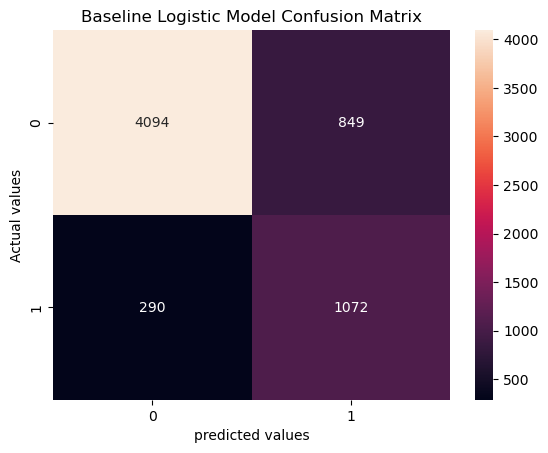

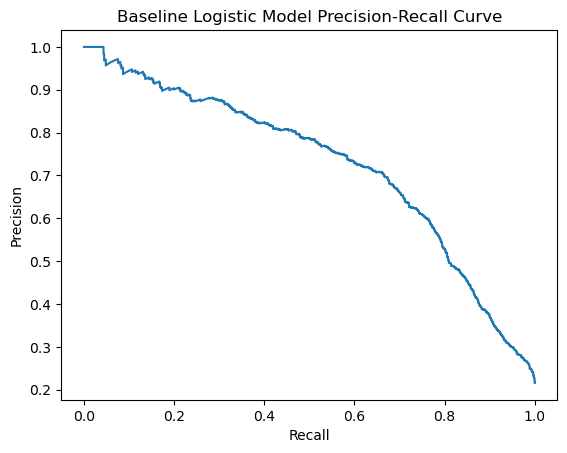

In [50]:
evaluate_model('Baseline Logistic Model', baseline_model,X_test,y_test)

In [ ]:
evaluate_model('XGBoost', xg_model,X_test,y_test)

## 10. XGBoost Hyperparameter Tuning

In [31]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(scale_pos_weight = scale_weights,random_state = 42,learning_rate = 0.1))
])
xg_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [32]:
from scipy.stats import uniform, randint


In [33]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "classifier__n_estimators":randint(150,600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01,0.5),
    "classifier__subsample": uniform(0.6,0.4),  # row sampling
    "classifier__colsample_bytree": uniform(0.6,0.4), # columns sampling
    "classifier__min_child_weight": randint(1,10),
    "classifier__gamma":uniform(0, 5)
}

# lower gamma -> more splits --> complex tree --> higher overfiting risk
# higher gamma --> less splits --> simple tree --> low overfiting risk

In [34]:
randomsearch = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv= cv,
    scoring='average_precision',
    n_jobs= -1,
    verbose= 1
)
randomsearch.fit(X_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002138B0D5A90>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002138B2728D0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002138B0D6DE0>},
                   scoring='average_precision', verbose=1)

In [35]:
randomsearch.best_params_

{'classifier__colsample_bytree': 0.750825097501217,
 'classifier__gamma': 0.24402062560722138,
 'classifier__learning_rate': 0.1129862740534736,
 'classifier__max_depth': 4,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 581,
 'classifier__subsample': 0.8539812180688156}

In [36]:
print(f"Score sfter performing Tuning {randomsearch.best_score_:.2f}")

Score sfter performing Tuning 0.90


## compare Both model side by side 

Accuracy : 0.82
threshold : 0.9996479749679565
Precision : 0.56
Recall : 0.79
f1 : 0.65

Logistic Regression calssification Report : 
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



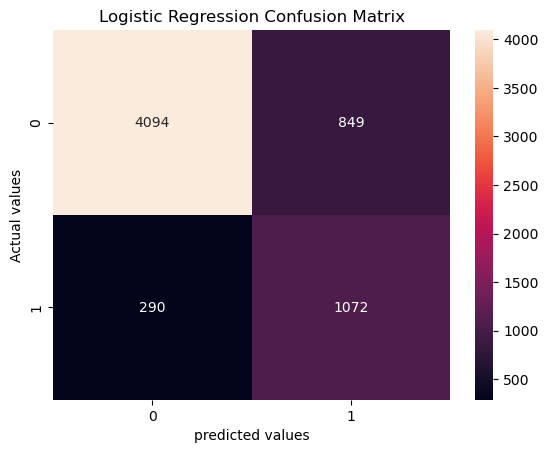

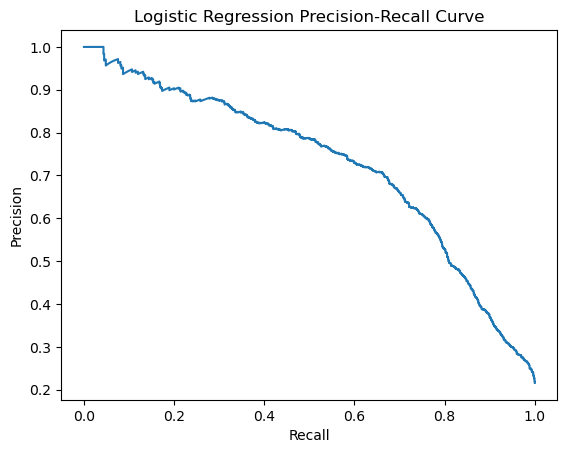

In [51]:
evaluate_model('Logistic Regression', baseline_model,X_test,y_test)

Accuracy : 0.91
threshold : 0.9996479749679565
Precision : 0.80
Recall : 0.80
f1 : 0.80

XGBoost calssification Report : 
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4943
           1       0.80      0.80      0.80      1362

    accuracy                           0.91      6305
   macro avg       0.87      0.87      0.87      6305
weighted avg       0.91      0.91      0.91      6305



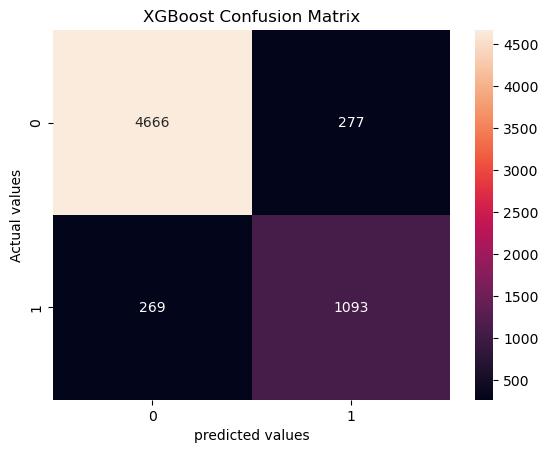

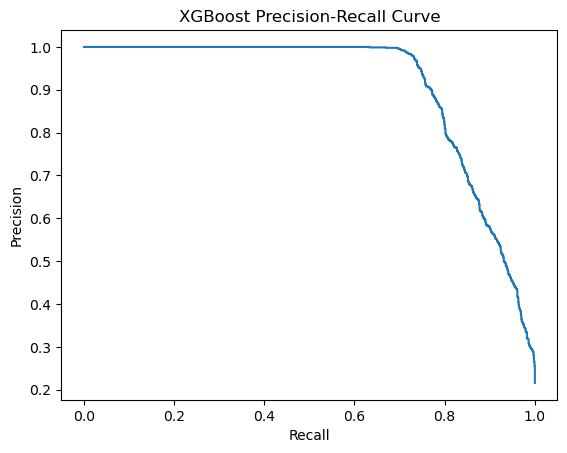

In [52]:
# Passing the model after the performing hyperparamter Tuning
evaluate_model("XGBoost", randomsearch,X_test,y_test)

## Optimizing the classification threshold

C:\Users\ankush kushwaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ankush kushwaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ankush kushwaha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ankush ku

Accuracy : 0.78
threshold : 0.9996479749679565
Precision : 0.00
Recall : 0.00
f1 : 0.00

XGBoost calssification Report : 
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



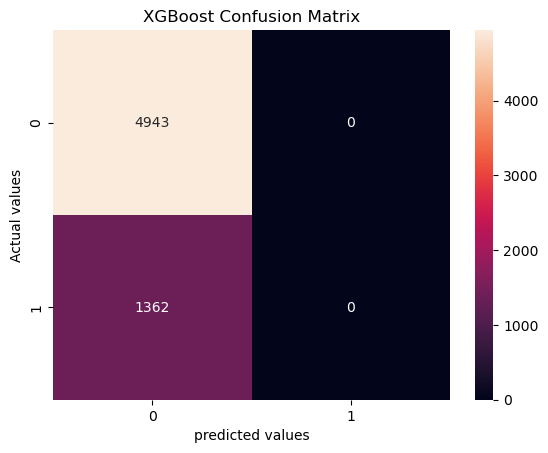

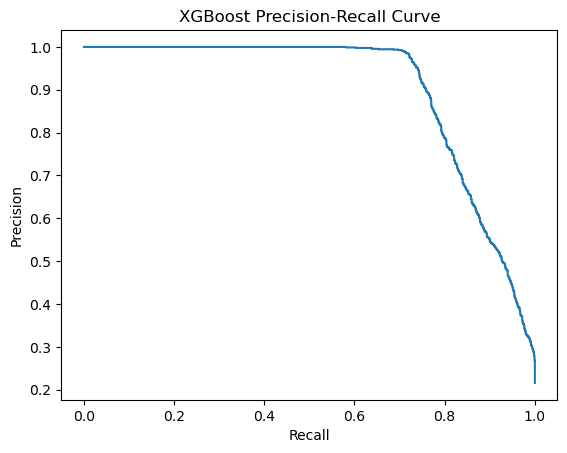

In [53]:
# get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:,1]
prob
# for each threshold calculate Precision and Recall
precision, recall, thresholds = precision_recall_curve(y_test,prob)
thresholds

# calculate F1 score for each threshold
f1 = 2* (precision - recall) / (precision + recall + 1e-9)
f1
# Get the threshold that produces t he highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model usnig that threshold
evaluate_model('XGBoost', xg_model,X_test,y_test,best_threshold)

## Probability calibration

In [54]:
"""
Methods by which we can fix the poorly calibrated model
1. Platt Scaling/sigmoid --> adjust the probability of the using the sigmoid curve
2. Isotonic Regression --> Learn a flexible mappig form old prob. better prob (non-linear)
3. Temprature scaling --> adjust the confidence of a neural netwokork predicition
"""

'\nMethods by which we can fix the poorly calibrated model\n1. Platt Scaling/sigmoid --> adjust the probability of the using the sigmoid curve\n2. Isotonic Regression --> Learn a flexible mappig form old prob. better prob (non-linear)\n3. Temprature scaling --> adjust the confidence of a neural netwokork predicition\n'

In [86]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
best_model = randomsearch.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv = 5
)
calibrated_model.fit(X_train,y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                gamma=0.24402062560722138,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.1129862740534736,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=4,
                                                                max_leaves=None,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=581,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [87]:
# 2. Get probability
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [88]:
# 3. Create calibration curve
actual_uncal, predicted_uncal = calibration_curve(y_test,uncalibrated,n_bins=10)

In [89]:
actual_cal, predicted_cal = calibration_curve(y_test,calibrated,n_bins=10)

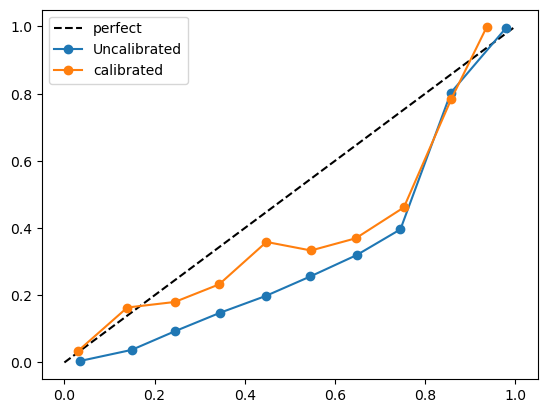

In [90]:
# 4. plot
plt.plot([0,1],[0,1], 'k--', label = 'perfect')
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "calibrated"
)
plt.legend()

# SHAP Interpretation -- Global & Local

In [91]:
# 1. Install SHAP if not exists
import shap

In [92]:
# GEt the Trained XGBoost classifier model out of the pipline
xgb_classifier = xg_model.named_steps['classifier']
xgb_classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [93]:
# Transform X_test using the same preproccesing used for training
X_test_transformed =  xg_model.named_steps['preprocessor'].transform(X_test)

In [94]:
# Get features names sfter one hot enconding, so plots readable
feature_names  = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [95]:
# convert to a dataframe for cleaner shap plots
X_test_df=  pd.DataFrame(X_test_transformed, columns=feature_names)



In [96]:
# create shap explainer built for tree based model
explainer = shap.TreeExplainer(xgb_classifier)

In [97]:
# calculate shap value for ecery row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.12646714e-01, -1.26755506e-01,  1.33791879e-01, ...,
        -5.45465993e-03, -2.11942941e-03,  0.00000000e+00],
       [-4.48196474e-03, -9.36791718e-01, -1.31195694e-01, ...,
        -7.36764725e-03, -7.80719239e-03,  0.00000000e+00],
       [ 9.69848782e-02,  3.64243174e+00,  1.15845121e-01, ...,
        -6.26665959e-03, -1.36033131e-03,  0.00000000e+00],
       ...,
       [ 1.35269035e-02,  5.85532665e-01,  8.45345184e-02, ...,
        -8.13906733e-03, -5.82884718e-03,  0.00000000e+00],
       [ 4.71081920e-02, -8.11781585e-01,  7.55942017e-02, ...,
        -9.23685916e-03, -7.67303910e-03,  0.00000000e+00],
       [-1.55267730e-01, -6.46857083e-01,  2.11317744e-02, ...,
        -8.27899296e-03, -5.55641949e-03,  0.00000000e+00]], dtype=float32)

### Global explaination

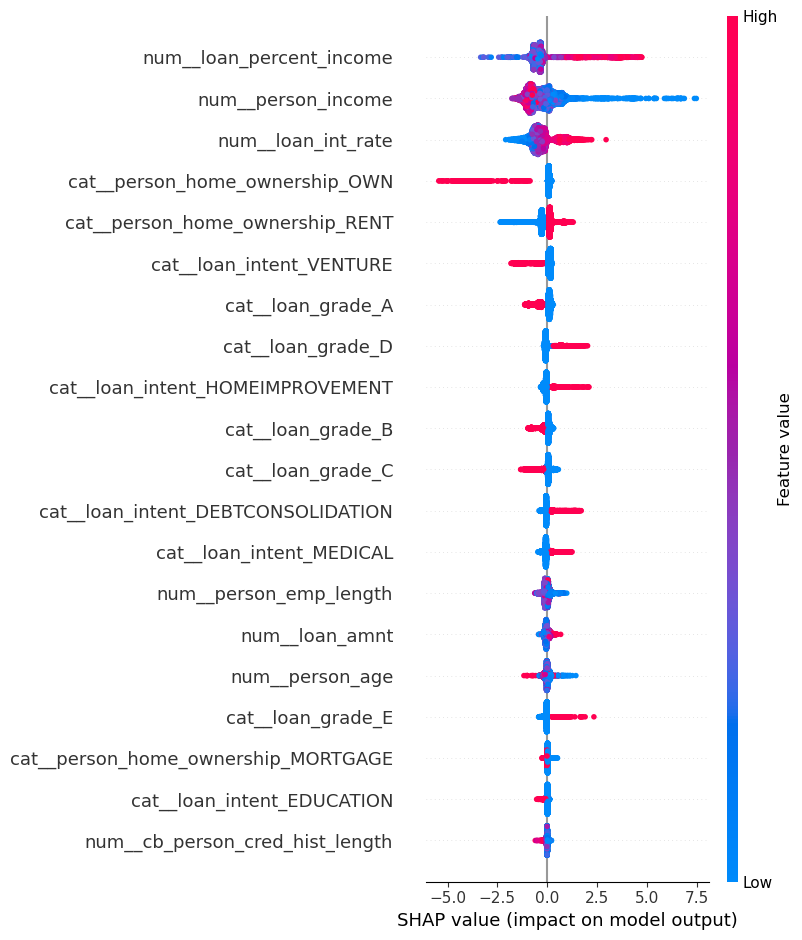

In [98]:
shap.summary_plot(shap_values,X_test_df)

### Local explaination 

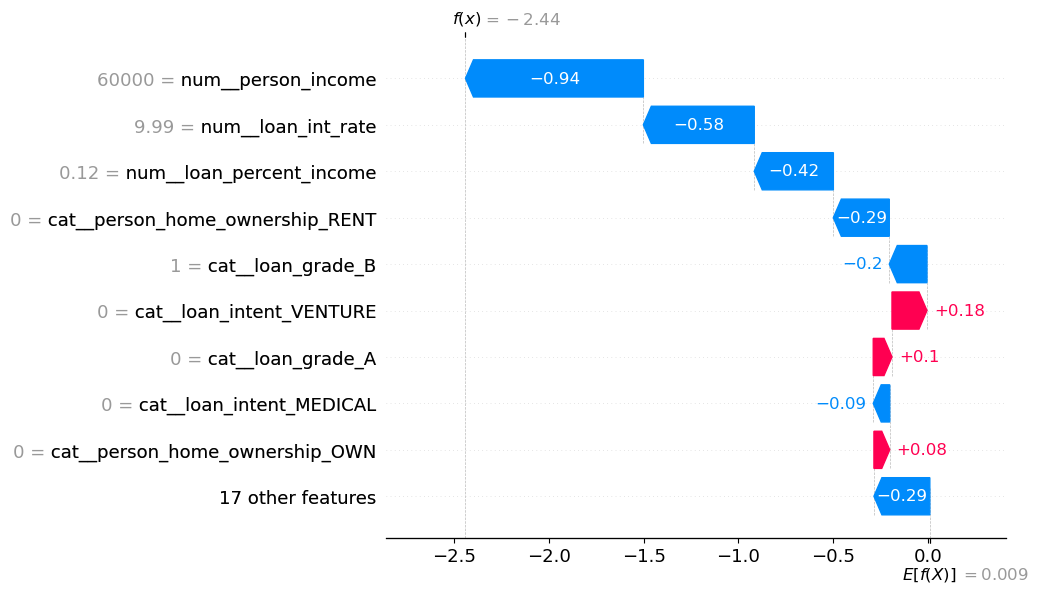

In [99]:
# pick one row to explain, e.g the 5th applicant in the test set
row_index = 5

# Drow a waterfall plot showing how each features pusshed the prediction up or down
shap.plots.waterfall(
    shap.Explanation(
        values= shap_values[row_index],
        base_values= explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names= feature_names
    )
)

## Analyzing False Positive & False Negatives

In [100]:
# Get prediction from best performing XGBoost model on the test set
y_pred = randomsearch.predict(X_test)

In [101]:
# Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [102]:
result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,1
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [103]:
# Indentify False Positive : Model Predicted 1, but the actual was 0 
false_positive= result_df[(result_df['actual'] == 0 )& (result_df['predicted'] ==1)]

# Indentify False negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual'] == 1) &( result_df['predicted'] ==0)]


In [104]:
print(f"False Positive : {len(false_positive)} " )
print(F"False negative : {len(false_negative)}")

False Positive : 277 
False negative : 269


In [105]:
# false positive > false negative 

## Save The Final Model 

In [106]:
import joblib
joblib.dump(calibrated_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [107]:
joblib.dump(best_threshold,'best_threshold.pkl')

['best_threshold.pkl']

In [109]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Het probabilities from the calibrated model , not hte old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now ono the correct probability scale
precision,recall,thresholds  = precision_recall_curve(y_test,calibrated_proba)
f1_scores = 2*(precision * recall)/(precision + recall * 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print('New threshold :', best_threshold)

New threshold : 0.013679413683712482
